In [8]:
# Python
import os
from pathlib import Path

# datascience and ML
import numpy as np
import matplotlib.pyplot as plt
import umap
import hdbscan

# torch
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T

# env
from dotenv import load_dotenv
load_dotenv()

# local
from ai_fractals.models import SelfSupervisedCNN, ShorelineVAE
from ai_fractals.data import ShorelineDataset, ShorelineWithBoundsDataset

In [9]:
# Paths
PROJECT_ROOT = Path(os.getenv("PROJECT_ROOT"))
DATASET = PROJECT_ROOT / "dataset" / "shoreline" / "evaluated"
REGION_DIR = PROJECT_ROOT / "dataset" / "region" / "evaluated"
MODELS_DIR = PROJECT_ROOT / "models"

cnn_model_path = MODELS_DIR / "self_supervised_cnn.pth"
vae_model_path = MODELS_DIR / "shoreline_vae.pth"

## 1. load models

In [10]:
# Transform (no augmentation!)
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
])

# create datasets and loaders
sh_dataset = ShorelineDataset(DATASET, transform=transform)
sh_wb_dataset = ShorelineWithBoundsDataset(
    shoreline_root=DATASET,
    region_root=REGION_DIR,
    transform=transform
)

sh_loader = DataLoader(sh_dataset, batch_size=32, shuffle=False)
sh_wb_loader = DataLoader(sh_wb_dataset, batch_size=32, shuffle=False)

# set device (common)
device = "cuda" if torch.cuda.is_available() else "cpu"

In [11]:
# Load self supervised CNN model
cnn_model = SelfSupervisedCNN(embedding_dim=256).to(device)
cnn_state = torch.load(cnn_model_path, map_location=device, weights_only=True)
cnn_model.load_state_dict(cnn_state)
cnn_model.eval()

SelfSupervisedCNN(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (projector): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
)

In [12]:
# load conditioned VAE modell
vae_model = ShorelineVAE(latent_dim=64, cond_dim=4).to(device)
vae_state = torch.load(vae_model_path, map_location=device, weights_only=True)
vae_model.load_state_dict(vae_state)
vae_model.eval()

ShorelineVAE(
  (enc): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=65540, out_features=64, bias=True)
  (fc_logvar): Linear(in_features=65540, out_features=64, bias=True)
  (fc_dec): Linear(in_features=68, out_features=65536, bias=True)
  (dec): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(32, 

## 2. generate synthetic shorelines

#### 2.1. create latent vector

In [13]:
# same latent dim as VAE
latent_dim = 64
num_samples = 1024

z = torch.randn(num_samples, latent_dim).to(device)
z

tensor([[-0.1084, -0.1916,  0.1630,  ...,  0.9117,  0.1598,  0.1379],
        [ 1.2663,  1.4229,  1.3115,  ..., -0.5189, -0.8984,  1.0655],
        [ 1.3757,  0.6076,  0.4964,  ...,  0.9036, -0.1822,  1.0075],
        ...,
        [ 1.0712, -1.1153, -0.9811,  ...,  1.8054,  1.7491,  1.5856],
        [-0.9303,  1.0317,  0.0154,  ...,  0.0328,  1.1234,  0.6322],
        [-0.8454, -0.5277,  0.2839,  ..., -1.5126, -1.6608,  0.4779]],
       device='cuda:0')

#### 2.2. get bounds

In [14]:
# get real bounds
real_bounds = []
for _, b in sh_wb_loader:
    real_bounds.append(b)
real_bounds = torch.cat(real_bounds, dim=0)
real_bounds

tensor([[-0.0896, -0.0886, -0.9634, -0.9624],
        [-0.0890, -0.0888, -0.9628, -0.9626],
        [-0.0889, -0.0889, -0.9627, -0.9627],
        ...,
        [ 0.2622,  0.2623,  0.6122,  0.6123],
        [ 0.2622,  0.2623,  0.6122,  0.6122],
        [ 0.2623,  0.2623,  0.6122,  0.6122]])

In [15]:
# chose random bounds from real
bounds = real_bounds[torch.randint(0, len(real_bounds), (num_samples,))]
bounds = bounds.to(device)
bounds

tensor([[-0.5859, -0.5247, -0.5746, -0.5134],
        [-1.1104, -1.1104,  0.2474,  0.2474],
        [-0.1634, -0.1634,  1.0261,  1.0261],
        ...,
        [-1.1866, -1.1866,  0.3050,  0.3050],
        [-1.7527, -1.7515, -0.0120, -0.0108],
        [-0.7141, -0.6529,  0.2652,  0.3264]], device='cuda:0')

#### 2.3. combine latent + bounds

In [16]:
z_cond = torch.cat([z, bounds], dim=1)
z_cond

tensor([[-0.1084, -0.1916,  0.1630,  ..., -0.5247, -0.5746, -0.5134],
        [ 1.2663,  1.4229,  1.3115,  ..., -1.1104,  0.2474,  0.2474],
        [ 1.3757,  0.6076,  0.4964,  ..., -0.1634,  1.0261,  1.0261],
        ...,
        [ 1.0712, -1.1153, -0.9811,  ..., -1.1866,  0.3050,  0.3050],
        [-0.9303,  1.0317,  0.0154,  ..., -1.7515, -0.0120, -0.0108],
        [-0.8454, -0.5277,  0.2839,  ..., -0.6529,  0.2652,  0.3264]],
       device='cuda:0')

#### 2.4. decode to synthetic shorelines

In [17]:
with torch.no_grad():
    dec_input = vae_model.fc_dec(z_cond)
    dec_input = dec_input.view(-1, 256, 16, 16)
    synthetic = vae_model.dec(dec_input)

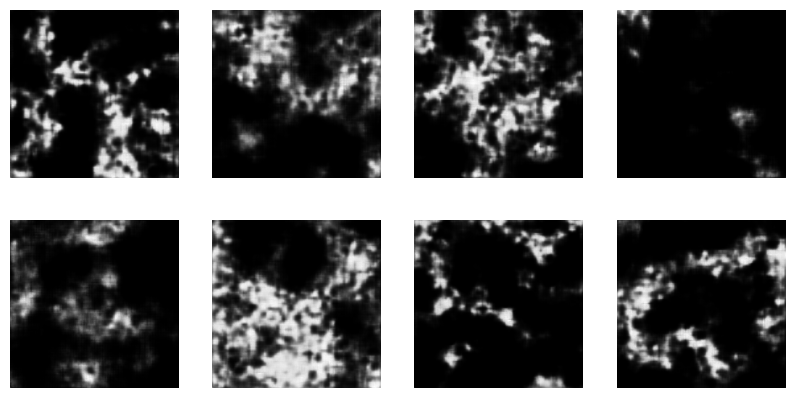

In [18]:
# first 8 synthetic shorelines
fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(synthetic[i, 0].cpu().numpy(), cmap="gray")
    ax.axis("off")

plt.show()

## 3. Create Embeddings

#### 3.1 Freeze CNN and create CNN-embeddings

In [19]:
cnn_embeddings = []

# freeze the model
cnn_model.eval()
for p in cnn_model.parameters():
    p.requires_grad = False

# create embeddings
with torch.no_grad():
    for batch in sh_loader:
        batch = batch.to(device)
        z = cnn_model(batch)  # forward pass gives embeddings
        cnn_embeddings.append(z.cpu().numpy())

cnn_embeddings = np.concatenate(cnn_embeddings, axis=0)
cnn_embeddings.shape

(10204, 256)

#### 3.2 Create synthetic embeddings 
Run synthetic shorelines through CNN

In [20]:
synthetic_embeddings = []

cnn_model.eval()
with torch.no_grad():
    for i in range(0, len(synthetic), 32):
        batch = synthetic[i:i+32].to(device)
        z = cnn_model(batch)
        synthetic_embeddings.append(z.cpu().numpy())

synthetic_embeddings = np.concatenate(synthetic_embeddings, axis=0)

## 4. UMAP test of real vs synthetic embeddings

The UMAP projection shows that synthetic embeddings do not collapse into a single region, but instead form several small, isolated clusters. These clusters appear in areas where the real manifold is relatively sparse, often between or slightly above denser regions of real embeddings.

This pattern suggests that the VAE is generating geometry that is *compatible* with the real manifold but not identical to any specific real cluster. The synthetic points tend to occupy “in‑between” zones — areas where UMAP places transitional geometry when the model interpolates between different real shoreline types.

The fact that synthetic clusters appear in multiple locations indicates that the VAE is exploring several parts of the latent space rather than producing one dominant mode. At the same time, the synthetic clusters remain close enough to real structures to confirm that the CNN encoder interprets them as plausible geometry.

Overall, the synthetic embeddings form small, scattered groups that sit near real structures without drifting far away, which is consistent with a VAE that interpolates and generalizes rather than memorizes.


In [21]:
um = umap.UMAP(
    n_neighbors=50,
    min_dist=0.05,
    metric="cosine",
    spread=1.5,
    local_connectivity=3,
)

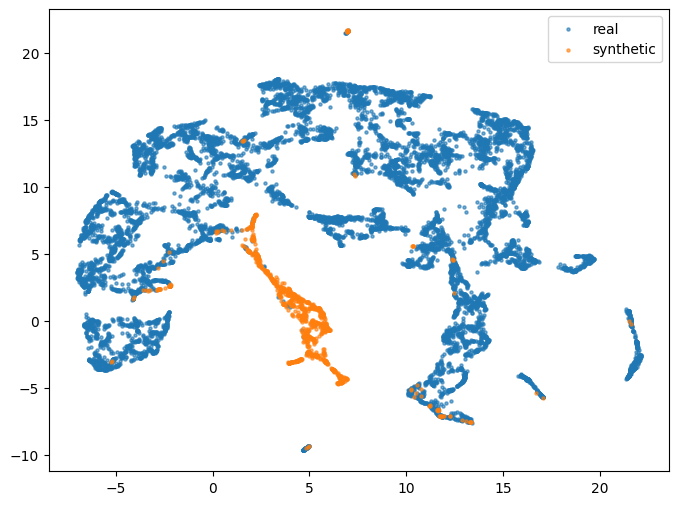

In [22]:
# concatenate embeddings
all_embeddings = np.concatenate([cnn_embeddings, synthetic_embeddings], axis=0)

# create labels: 0 = real, 1 = synthetic
labels = np.array(
    [0] * len(cnn_embeddings) +
    [1] * len(synthetic_embeddings)
)

points = um.fit_transform(all_embeddings)

# plot
plt.figure(figsize=(8, 6))
plt.scatter(points[labels==0, 0], points[labels==0, 1], s=5, alpha=0.6, label="real")
plt.scatter(points[labels==1, 0], points[labels==1, 1], s=5, alpha=0.6, label="synthetic")
plt.legend()
plt.show()


## 5. CNN Interpolation 

The interpolation points (magenta) form a continuous path between two selected embeddings. They stay close to the real manifold and do not drift into empty regions. In the plot, the interpolation line sits near the central part of the structure, close to the boundary of one of the real clusters. This indicates that the interpolation moves through a region where real embeddings exist, but where density is lower.

The interpolation does not follow the synthetic clusters. Instead, it traces a direct geometric transition between the two chosen embeddings. This is expected: interpolation is a controlled movement between two known points, while synthetic samples come from random latent sampling and therefore explore different parts of the space.

The code selects two embeddings, `a` and `b`, and creates a sequence of intermediate points:

`interp[t] = (1 - t) * a + t * b`


This produces a smooth line in embedding space. Each interpolated point is literally a weighted average between a real embedding and another real embedding. UMAP then projects this line into 2D, which is why you see a magenta curve between the two regions.

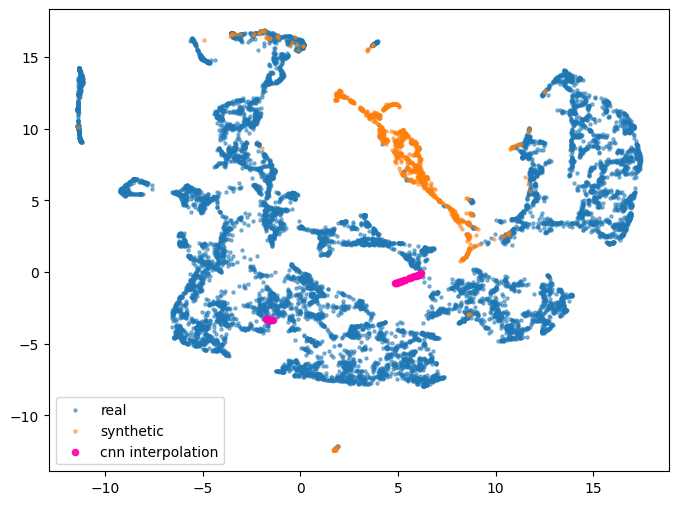

In [23]:
# choose två embeddings to interpolate
a = cnn_embeddings[10]
b = cnn_embeddings[200]

# create interpolation in latent space (linear)
steps = 32
interpolation = np.array([
    a * (1 - t) + b * t
    for t in np.linspace(0, 1, steps)
])

# concat all for UMAP
all_embeddings = np.concatenate([
    cnn_embeddings,
    synthetic_embeddings,
    interpolation
], axis=0)

labels = np.array(
    [0] * len(cnn_embeddings) +
    [1] * len(synthetic_embeddings) +
    [2] * len(interpolation)
)

points = um.fit_transform(all_embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(points[labels==0, 0], points[labels==0, 1], s=5, alpha=0.5, label="real")
plt.scatter(points[labels==1, 0], points[labels==1, 1], s=5, alpha=0.5, label="synthetic")
plt.scatter(points[labels==2, 0], points[labels==2, 1], s=20, c="#ff00aa", alpha=0.9, label="cnn interpolation")
plt.legend()
plt.show()


### Interpretation

The interpolation points behave correctly:

- they stay inside the manifold  
- they move through a low‑density region rather than leaving the structure  
- they show how the model transitions between two real shoreline types  
- they do not collapse or jump to synthetic clusters  

This confirms that the embedding space is continuous and that interpolations produce plausible intermediate geometry.


## 6. VAE interpolation

The VAE interpolation points show how the model organizes shoreline geometry inside its latent space. The purple samples come from decoding latent vectors that were linearly interpolated between two real shoreline encodings. Because the VAE learns a continuous latent manifold, these interpolated latents produce shoreline shapes that transition smoothly between the two originals.

The interpolation path stays inside the region occupied by real data rather than drifting outward. This indicates that the VAE has learned a coherent latent structure: moving between two latent codes produces shapes that the CNN recognizes as valid shoreline geometry. 


In [24]:
# Two real shoreline samples
s1, b1 = sh_wb_dataset[10]
s2, b2 = sh_wb_dataset[200]

# batch dimension
s1 = s1.unsqueeze(0).to(device)   # (1, 1, 256, 256)
s2 = s2.unsqueeze(0).to(device)
b1 = b1.unsqueeze(0).to(device)   # (1, 4)
b2 = b2.unsqueeze(0).to(device)

# encode to latent space
with torch.no_grad():
    mu1, _ = vae_model.encode(s1, b1)   # (1, 64)
    mu2, _ = vae_model.encode(s2, b2)

# remove batch dim -> (64,)
mu1 = mu1.squeeze(0)
mu2 = mu2.squeeze(0)

# interpolate in latent space -> (steps, 64)
steps = 32
z_interp = torch.stack([
    (1 - t) * mu1 + t * mu2
    for t in torch.linspace(0, 1, steps)
]).to(device)

# bounds -> (steps, 4)
bounds_interp = b1.squeeze(0).repeat(steps, 1)

print("cnn_embeddings shape: ", cnn_embeddings.shape)
print("synthetic_embeddings shape: ", synthetic_embeddings.shape)
print("mu1 shape:", mu1.shape)
print("mu2 shape:", mu2.shape)
print("z_interp shape:", z_interp.shape)
print("bounds_interp shape:", bounds_interp.shape)


cnn_embeddings shape:  (10204, 256)
synthetic_embeddings shape:  (1024, 256)
mu1 shape: torch.Size([64])
mu2 shape: torch.Size([64])
z_interp shape: torch.Size([32, 64])
bounds_interp shape: torch.Size([32, 4])


interp_embeddings shape: (32, 256)


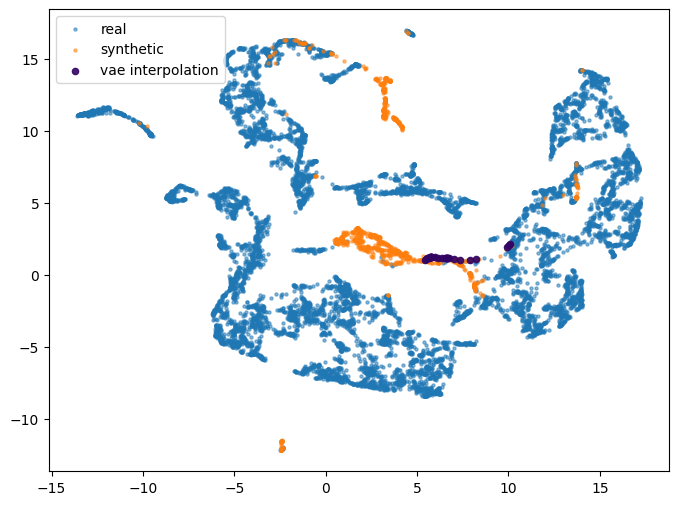

In [25]:
# decode to new synthetic shorelines
with torch.no_grad():
    decoded = vae_model.decode(z_interp, bounds_interp)

# get CNN embeddings for the decoded interpolation
interp_embeddings = cnn_model(decoded).cpu().numpy()
print("interp_embeddings shape:", interp_embeddings.shape)

# concat all for UMAP
all_embeddings = np.concatenate([
    cnn_embeddings,
    synthetic_embeddings,
    interp_embeddings
], axis=0)

labels = np.array(
    [0] * len(cnn_embeddings) +
    [1] * len(synthetic_embeddings) +
    [2] * len(interp_embeddings)
)

points = um.fit_transform(all_embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(points[labels==0, 0], points[labels==0, 1], s=5, alpha=0.5, label="real")
plt.scatter(points[labels==1, 0], points[labels==1, 1], s=5, alpha=0.5, label="synthetic")
plt.scatter(points[labels==2, 0], points[labels==2, 1], s=20, c="#330564", alpha=0.9, label="vae interpolation")
plt.legend()
plt.show()


In [26]:
decoded = vae_model.decode(z_interp, bounds_interp)


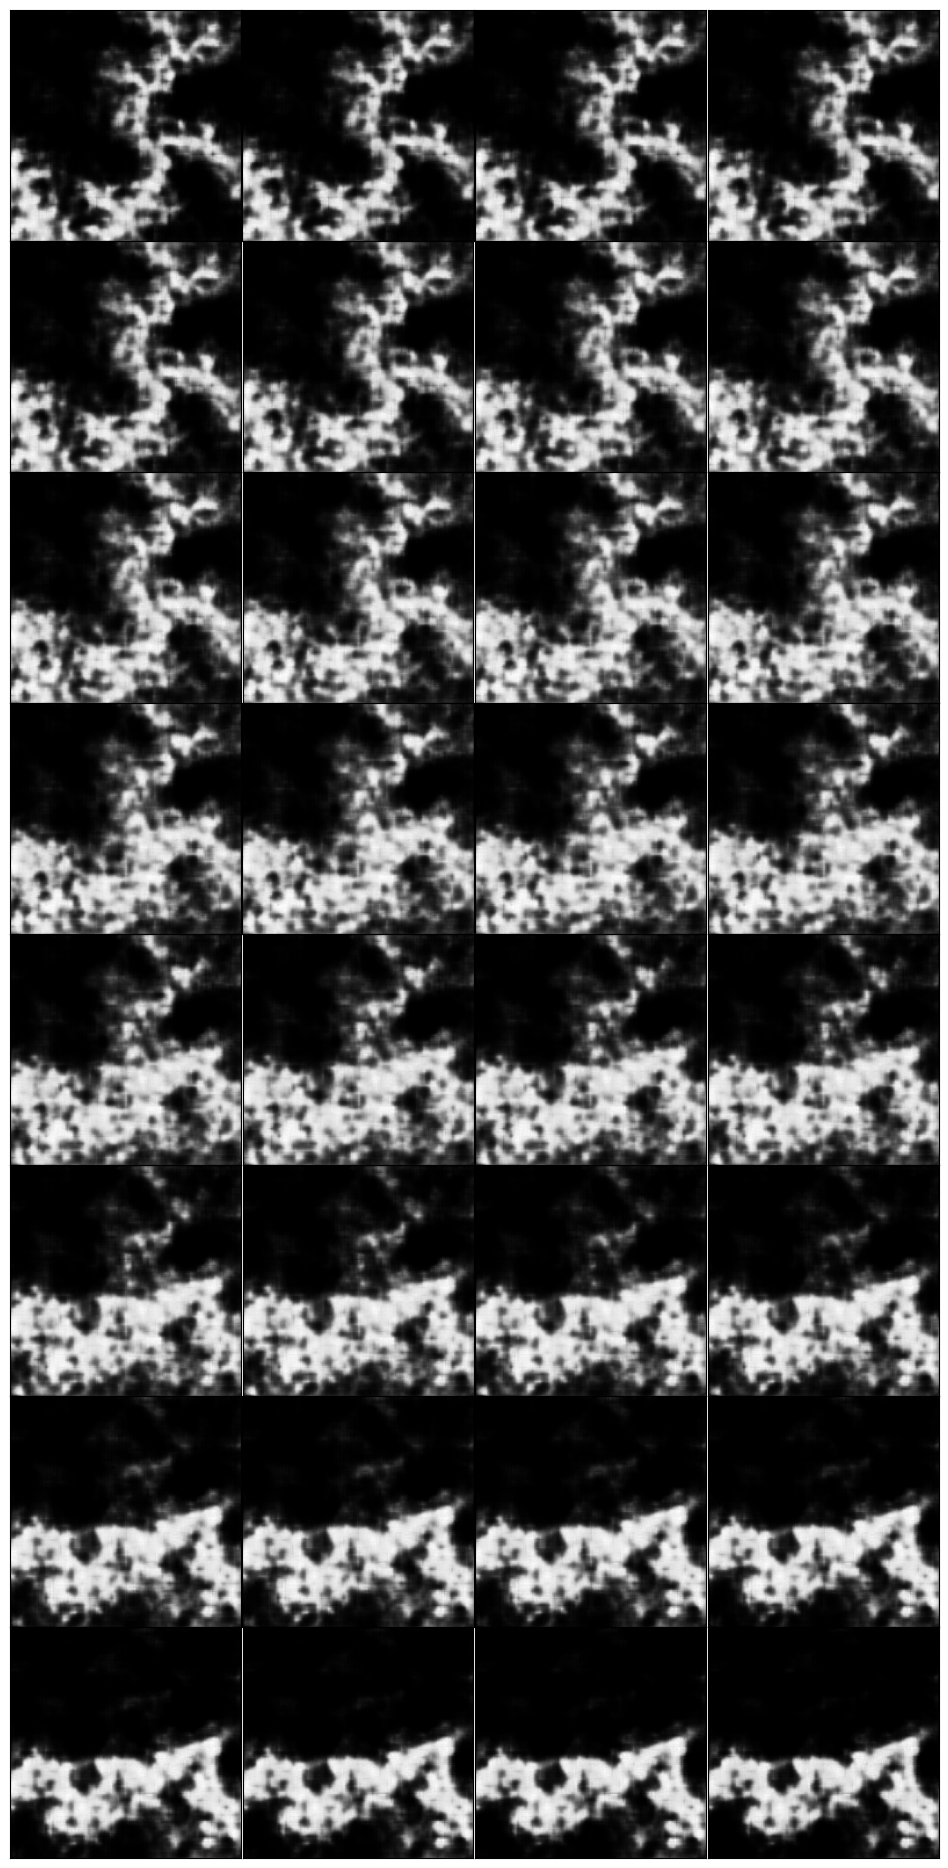

In [ ]:
fig, axes = plt.subplots(8, 4, figsize=(12, 24))

for ax, i in zip(axes.flatten(), range(32)):
    ax.imshow(decoded[i, 0].detach().cpu().numpy(), cmap="gray")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()